<a href="https://colab.research.google.com/github/NiteshJ98/LLM-from-scratch/blob/main/Layer%201/Phase%203/Backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Backpropagation is the single most important algorithm to understand in deep learning. Every other concept — gradient descent, optimizers, fine-tuning — assumes you understand this. Let's build it completely from scratch, with the math and code running in parallel.

The core idea
A neural network makes a prediction. The prediction is wrong by some amount — that's the loss. Backprop answers the question: *for every single weight in the network, if I nudge it slightly, how much does the loss change?* That answer — the gradient — is what the optimizer uses to improve the weights.

The key insight is the chain rule: if loss depends on A, and A depends on B, and B depends on weight W, then:


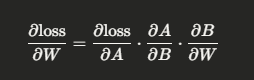

Backprop is just the chain rule applied systematically across every operation in the network, walking backward from loss to inputs.


**The network we'll work through**

A minimal network: 2 inputs → 1 hidden unit → 1 output → MSE loss. Small enough to do by hand, large enough to show the full mechanism.

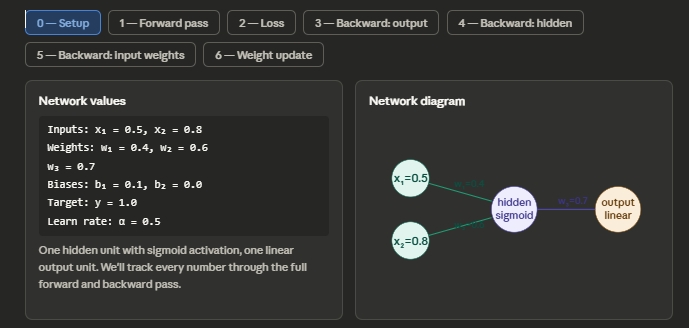




In [ ]:
import torch
import torch.nn as nn

# ─────────────────────────────────────────────
# STEP 0 — Set up weights and inputs
# ─────────────────────────────────────────────

# All requires_grad=True so PyTorch tracks operations
w1 = torch.tensor(0.4, requires_grad=True)
w2 = torch.tensor(0.6, requires_grad=True)
w3 = torch.tensor(0.7, requires_grad=True)
b1 = torch.tensor(0.1, requires_grad=True)
b2 = torch.tensor(0.0, requires_grad=True)

x1 = torch.tensor(0.5)   # inputs don't need grad
x2 = torch.tensor(0.8)
y  = torch.tensor(1.0)   # target

lr = 0.5

print("=" * 50)
print("INITIAL WEIGHTS")
print(f"  w1={w1.item():.4f}  w2={w2.item():.4f}  w3={w3.item():.4f}")
print(f"  b1={b1.item():.4f}  b2={b2.item():.4f}")

INITIAL WEIGHTS
  w1=0.4000  w2=0.6000  w3=0.7000
  b1=0.1000  b2=0.0000


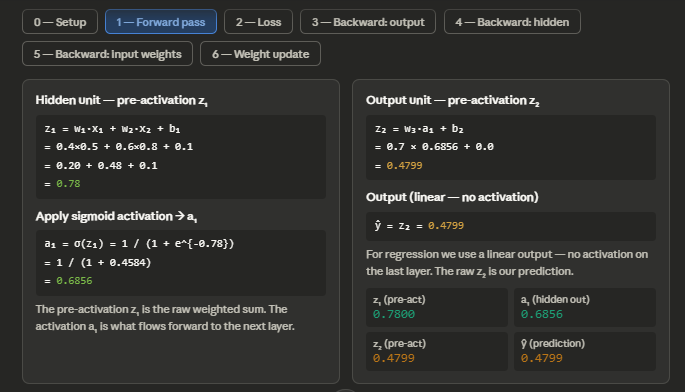

In [ ]:
# ─────────────────────────────────────────────
# STEP 1 — Forward pass
# ─────────────────────────────────────────────

# Hidden unit — weighted sum then sigmoid
z1 = w1 * x1 + w2 * x2 + b1
a1 = torch.sigmoid(z1)

# Output unit — linear (no activation)
z2 = w3 * a1 + b2
y_hat = z2    # prediction

print("\nFORWARD PASS")
print(f"  z1 = {z1.item():.4f}  (pre-activation hidden)")
print(f"  a1 = {a1.item():.4f}  (sigmoid output hidden)")
print(f"  z2 = {z2.item():.4f}  (pre-activation output)")
print(f"  ŷ  = {y_hat.item():.4f}  (prediction)")


FORWARD PASS
  z1 = 0.7800  (pre-activation hidden)
  a1 = 0.6857  (sigmoid output hidden)
  z2 = 0.4800  (pre-activation output)
  ŷ  = 0.4800  (prediction)


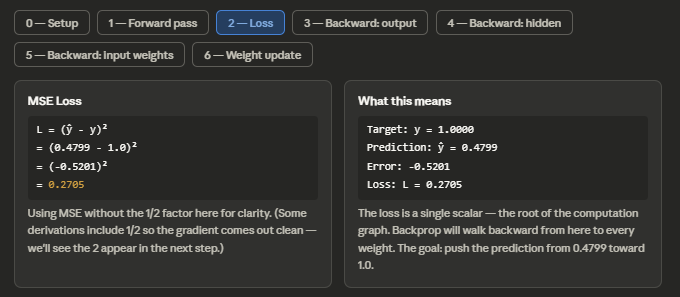

In [ ]:
# ─────────────────────────────────────────────
# STEP 2 — Compute loss
# ─────────────────────────────────────────────

loss = (y_hat - y) ** 2

print("\nLOSS")
print(f"  target = {y.item():.4f}")
print(f"  pred   = {y_hat.item():.4f}")
print(f"  error  = {(y_hat - y).item():.4f}")
print(f"  loss   = {loss.item():.4f}")


LOSS
  target = 1.0000
  pred   = 0.4800
  error  = -0.5200
  loss   = 0.2704


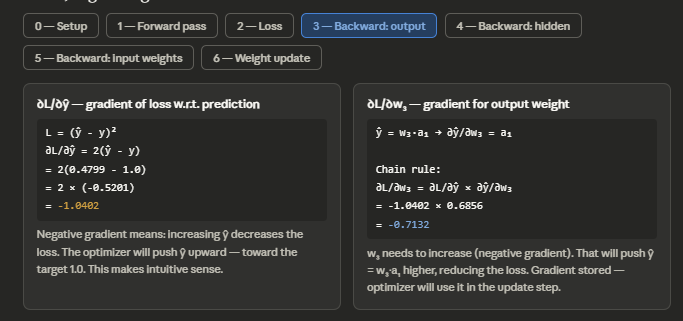

In [ ]:
# ─────────────────────────────────────────────
# STEP 3 — Backward pass
# ─────────────────────────────────────────────

# Single call — PyTorch walks the graph backward,
# applies chain rule at every node, fills .grad
loss.backward()

print("\nGRADIENTS (computed by autograd)")
print(f"  ∂L/∂w3 = {w3.grad.item():.4f}")
print(f"  ∂L/∂w1 = {w1.grad.item():.4f}")
print(f"  ∂L/∂w2 = {w2.grad.item():.4f}")
print(f"  ∂L/∂b1 = {b1.grad.item():.4f}")
print(f"  ∂L/∂b2 = {b2.grad.item():.4f}")


GRADIENTS (computed by autograd)
  ∂L/∂w3 = -0.7131
  ∂L/∂w1 = -0.0785
  ∂L/∂w2 = -0.1255
  ∂L/∂b1 = -0.1569
  ∂L/∂b2 = -1.0400


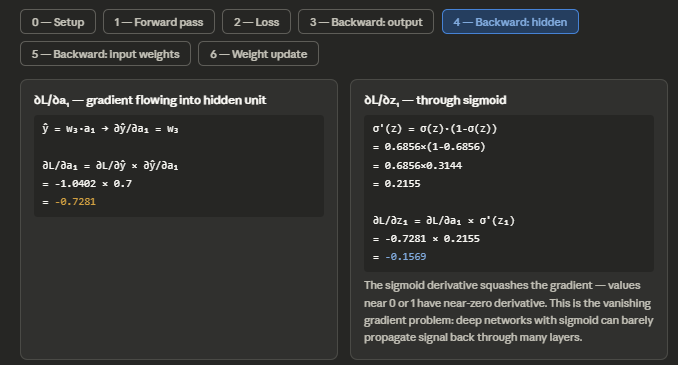

In [ ]:
# ─────────────────────────────────────────────
# STEP 4 — Manual verification (chain rule by hand)
# ─────────────────────────────────────────────

# Recompute without grad for manual check
z1_v = 0.4 * 0.5 + 0.6 * 0.8 + 0.1    # 0.78
a1_v = 1 / (1 + 2.718**(-z1_v))         # sigmoid ≈ 0.6856
z2_v = 0.7 * a1_v                        # 0.4799
y_hat_v = z2_v                           # 0.4799

dL_dyhat = 2 * (y_hat_v - 1.0)          # -1.0402
dL_dw3   = dL_dyhat * a1_v              # -1.0402 * 0.6856 = -0.7132
dL_da1   = dL_dyhat * 0.7               # -1.0402 * 0.7   = -0.7281
sigmoid_deriv = a1_v * (1 - a1_v)        # 0.6856 * 0.3144 = 0.2155
dL_dz1   = dL_da1 * sigmoid_deriv       # -0.7281 * 0.2155 = -0.1569
dL_dw1   = dL_dz1 * 0.5                 # -0.1569 * x1   = -0.0785
dL_dw2   = dL_dz1 * 0.8                 # -0.1569 * x2   = -0.1255

print("\nMANUAL VERIFICATION")
print(f"  ∂L/∂w3 manual = {dL_dw3:.4f}  autograd = {w3.grad.item():.4f}")
print(f"  ∂L/∂w1 manual = {dL_dw1:.4f}  autograd = {w1.grad.item():.4f}")
print(f"  ∂L/∂w2 manual = {dL_dw2:.4f}  autograd = {w2.grad.item():.4f}")


MANUAL VERIFICATION
  ∂L/∂w3 manual = -0.7131  autograd = -0.7131
  ∂L/∂w1 manual = -0.0785  autograd = -0.0785
  ∂L/∂w2 manual = -0.1255  autograd = -0.1255


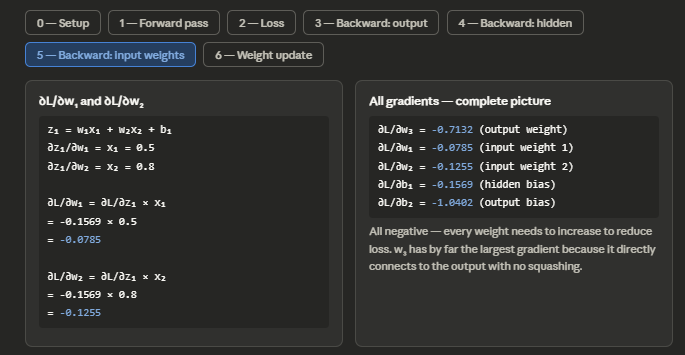

In [ ]:
# ─────────────────────────────────────────────
# STEP 5 — Weight update (SGD)
# ─────────────────────────────────────────────

# torch.no_grad() so the update itself isn't tracked
with torch.no_grad():
    w1 -= lr * w1.grad
    w2 -= lr * w2.grad
    w3 -= lr * w3.grad
    b1 -= lr * b1.grad
    b2 -= lr * b2.grad

print("\nWEIGHTS AFTER UPDATE")
print(f"  w1={w1.item():.4f}  w2={w2.item():.4f}  w3={w3.item():.4f}")
print(f"  b1={b1.item():.4f}  b2={b2.item():.4f}")


WEIGHTS AFTER UPDATE
  w1=0.4392  w2=0.6628  w3=1.0566
  b1=0.1785  b2=0.5200


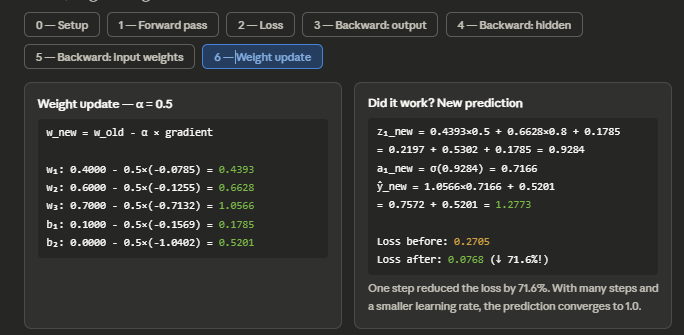

In [ ]:
# ─────────────────────────────────────────────
# STEP 6 — New prediction with updated weights
# ─────────────────────────────────────────────

z1_new   = w1 * x1 + w2 * x2 + b1
a1_new   = torch.sigmoid(z1_new)
y_hat_new = w3 * a1_new + b2
loss_new  = (y_hat_new - y) ** 2

print("\nAFTER ONE UPDATE")
print(f"  prediction: {y_hat.item():.4f} → {y_hat_new.item():.4f}")
print(f"  loss:       {loss.item():.4f} → {loss_new.item():.4f}")
print(f"  improvement: {(1 - loss_new/loss).item()*100:.1f}%")


AFTER ONE UPDATE
  prediction: 0.4800 → 1.2773
  loss:       0.2704 → 0.0769
  improvement: 71.6%


**Now run it for 100 steps and watch it converge**

In [ ]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)

# Reinitialize
w1 = torch.tensor(0.4, requires_grad=True)
w2 = torch.tensor(0.6, requires_grad=True)
w3 = torch.tensor(0.7, requires_grad=True)
b1 = torch.tensor(0.1, requires_grad=True)
b2 = torch.tensor(0.0, requires_grad=True)

x1, x2, y = torch.tensor(0.5), torch.tensor(0.8), torch.tensor(1.0)
lr = 0.1

losses = []
predictions = []

for step in range(100):
    # Zero gradients — critical, otherwise they accumulate
    for w in [w1, w2, w3, b1, b2]:
        if w.grad is not None:
            w.grad.zero_()

    # Forward
    a1   = torch.sigmoid(w1*x1 + w2*x2 + b1)
    yhat = w3 * a1 + b2
    loss = (yhat - y)**2

    # Backward
    loss.backward()

    # Update
    with torch.no_grad():
        w1 -= lr * w1.grad
        w2 -= lr * w2.grad
        w3 -= lr * w3.grad
        b1 -= lr * b1.grad
        b2 -= lr * b2.grad

    losses.append(loss.item())
    predictions.append(yhat.item())

    if step % 10 == 0:
        print(f"Step {step:3d} | loss={loss.item():.5f} | pred={yhat.item():.4f}")

Step   0 | loss=0.27042 | pred=0.4800
Step  10 | loss=0.00016 | pred=0.9874
Step  20 | loss=0.00000 | pred=0.9997
Step  30 | loss=0.00000 | pred=1.0000
Step  40 | loss=0.00000 | pred=1.0000
Step  50 | loss=0.00000 | pred=1.0000
Step  60 | loss=0.00000 | pred=1.0000
Step  70 | loss=0.00000 | pred=1.0000
Step  80 | loss=0.00000 | pred=1.0000
Step  90 | loss=0.00000 | pred=1.0000



Final prediction: 1.00000  (target: 1.0)


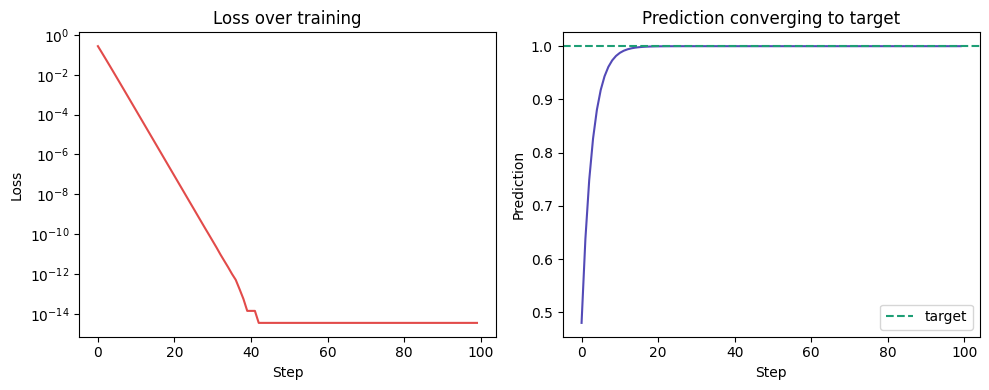

In [ ]:
print(f"\nFinal prediction: {predictions[-1]:.5f}  (target: 1.0)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(losses, color='#E24B4A')
ax1.set(xlabel='Step', ylabel='Loss', title='Loss over training', yscale='log')
ax2.plot(predictions, color='#534AB7')
ax2.axhline(1.0, color='#1D9E75', linestyle='--', label='target')
ax2.set(xlabel='Step', ylabel='Prediction', title='Prediction converging to target')
ax2.legend()
plt.tight_layout(); plt.show()

**Implementing backprop from scratch — no autograd**

This is the exercise that makes everything permanent. Compute every gradient by hand, then verify against PyTorch.

In [ ]:
import torch
import math

# Fixed values
x1, x2, y_true = 0.5, 0.8, 1.0
w1, w2, w3 = 0.4, 0.6, 0.7
b1, b2     = 0.1, 0.0
lr         = 0.1

def sigmoid(z): return 1 / (1 + math.exp(-z))
def sigmoid_grad(z): s = sigmoid(z); return s * (1 - s)

losses_manual = []

for step in range(50):
    # ── FORWARD ──────────────────────────────────
    z1   = w1*x1 + w2*x2 + b1
    a1   = sigmoid(z1)
    yhat = w3*a1 + b2
    loss = (yhat - y_true)**2

    # ── BACKWARD — chain rule by hand ────────────
    # Layer 3: output
    dL_dyhat = 2 * (yhat - y_true)   # ∂L/∂ŷ
    dL_dw3   = dL_dyhat * a1          # ∂L/∂w3 = ∂L/∂ŷ · ∂ŷ/∂w3
    dL_db2   = dL_dyhat               # ∂L/∂b2 = ∂L/∂ŷ · 1

    # Layer 2: hidden → output
    dL_da1 = dL_dyhat * w3            # ∂L/∂a1 = ∂L/∂ŷ · ∂ŷ/∂a1
    dL_dz1 = dL_da1 * sigmoid_grad(z1) # ∂L/∂z1 = ∂L/∂a1 · σ'(z1)

    # Layer 1: input → hidden
    dL_dw1 = dL_dz1 * x1             # ∂L/∂w1 = ∂L/∂z1 · x1
    dL_dw2 = dL_dz1 * x2             # ∂L/∂w2 = ∂L/∂z1 · x2
    dL_db1 = dL_dz1                   # ∂L/∂b1 = ∂L/∂z1 · 1

    # ── UPDATE ───────────────────────────────────
    w1 -= lr * dL_dw1
    w2 -= lr * dL_dw2
    w3 -= lr * dL_dw3
    b1 -= lr * dL_db1
    b2 -= lr * dL_db2

    losses_manual.append(loss)

    if step % 10 == 0:
        print(f"Step {step:3d} | loss={loss:.5f} | pred={yhat:.4f}")

# ── VERIFY AGAINST PYTORCH AUTOGRAD ──────────────
print("\nVerifying manual gradients against PyTorch autograd...")

w1t = torch.tensor(0.4, requires_grad=True)
w2t = torch.tensor(0.6, requires_grad=True)
w3t = torch.tensor(0.7, requires_grad=True)
b1t = torch.tensor(0.1, requires_grad=True)
b2t = torch.tensor(0.0, requires_grad=True)
x1t = torch.tensor(0.5)
x2t = torch.tensor(0.8)
yt  = torch.tensor(1.0)

a1t   = torch.sigmoid(w1t*x1t + w2t*x2t + b1t)
yhatt = w3t * a1t + b2t
losst = (yhatt - yt)**2
losst.backward()

# Manual gradients at step 0 (before any updates)
w1_, w2_, w3_, b1_, b2_ = 0.4, 0.6, 0.7, 0.1, 0.0
z1_ = w1_*0.5 + w2_*0.8 + b1_
a1_ = sigmoid(z1_)
yh_ = w3_*a1_ + b2_
dLdy = 2*(yh_ - 1.0)
gw3 = dLdy * a1_
gdz1 = dLdy * w3_ * sigmoid_grad(z1_)
gw1 = gdz1 * 0.5
gw2 = gdz1 * 0.8

print(f"  w1: manual={gw1:.6f}  autograd={w1t.grad.item():.6f}  match={abs(gw1-w1t.grad.item())<1e-5}")
print(f"  w2: manual={gw2:.6f}  autograd={w2t.grad.item():.6f}  match={abs(gw2-w2t.grad.item())<1e-5}")
print(f"  w3: manual={gw3:.6f}  autograd={w3t.grad.item():.6f}  match={abs(gw3-w3t.grad.item())<1e-5}")

Step   0 | loss=0.27042 | pred=0.4800
Step  10 | loss=0.00016 | pred=0.9874
Step  20 | loss=0.00000 | pred=0.9997
Step  30 | loss=0.00000 | pred=1.0000
Step  40 | loss=0.00000 | pred=1.0000

Verifying manual gradients against PyTorch autograd...
  w1: manual=-0.078454  autograd=-0.078454  match=True
  w2: manual=-0.125526  autograd=-0.125526  match=True
  w3: manual=-0.713140  autograd=-0.713140  match=True


**The four things to internalize**

The gradient is a sensitivity score.` ∂L/∂w = -0.71` means: nudge w by +0.01 and loss drops by ~0.0071. The sign tells direction, the magnitude tells how much leverage that weight has.

Deeper weights get smaller gradients. Look at the numbers — `∂L/∂w3 = -0.713` but `∂L/∂w1 = -0.079`. The gradient shrank by ~9× passing through the sigmoid. With 10 layers each squashing by ~0.25, the gradient at the first layer is essentially zero. This is the vanishing gradient problem — why ReLU replaced sigmoid, and why transformers use residual connections.

`loss.backward()` is just a for loop over operations. PyTorch walks the graph from loss back to every leaf, applies the local derivative at each node, multiplies using chain rule. There's no magic — it's systematic bookkeeping.

Zero gradients or they accumulate. If you forget `optimizer.zero_grad()`, gradients from step 1 are still in `.grad` when step 2 runs. The update uses the sum of all previous gradients — completely wrong. This is one of the most common bugs in PyTorch training loops.